In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
!wget -q https://data.nasa.gov/docs/legacy/CMAPSSData.zip -O CMAPSSData.zip
!unzip -q CMAPSSData.zip -d CMAPSSData

print("Dataset downloaded successfully")

Dataset downloaded successfully


In [3]:
!ls

CMAPSSData  CMAPSSData.zip  sample_data


In [4]:
!find . -name "train_FD001.txt"

./CMAPSSData/train_FD001.txt


In [5]:
train_path = "CMAPSSData/train_FD001.txt"

train_df = pd.read_csv(
    train_path,
    sep=r"\s+",
    header=None
)

print("Shape:", train_df.shape)
train_df.head()

Shape: (20631, 26)


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [6]:
print("Rows:", train_df.shape[0])
print("Columns:", train_df.shape[1])

Rows: 20631
Columns: 26


In [7]:
columns = [
    "unit_id",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]

train_df.columns = columns

train_df.head()

,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [8]:
train_df[[
    "unit_id",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3"
]].head(10)

,unit_id,cycle,setting_1,setting_2,setting_3
0,1,1,-0.0007,-0.0004,100.0
1,1,2,0.0019,-0.0003,100.0
2,1,3,-0.0043,0.0003,100.0
3,1,4,0.0007,0.0000,100.0
4,1,5,-0.0019,-0.0002,100.0
5,1,6,-0.0043,-0.0001,100.0
6,1,7,0.0010,0.0001,100.0
7,1,8,-0.0034,0.0003,100.0
8,1,9,0.0008,0.0001,100.0
9,1,10,-0.0033,0.0001,100.0


In [9]:
train_df["unit_id"].nunique()

100

In [10]:
train_df.groupby("unit_id")["cycle"].max().head(10)

,cycle
unit_id,
1,192
2,287
3,179
4,189
5,269
6,188
7,259
8,150
9,201


In [11]:
# Find the final cycle for every engine
max_cycle = train_df.groupby("unit_id")["cycle"].max()

# Add the final cycle to every row
train_df["max_cycle"] = train_df["unit_id"].map(max_cycle)

# Calculate Remaining Useful Life
train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]

train_df.head()

,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [12]:
train_df[train_df["unit_id"] == 1][
    ["unit_id", "cycle", "max_cycle", "RUL"]
].head(10)

,unit_id,cycle,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187
5,1,6,192,186
6,1,7,192,185
7,1,8,192,184
8,1,9,192,183
9,1,10,192,182


In [13]:
train_df[train_df["unit_id"] == 1][
    ["unit_id", "cycle", "max_cycle", "RUL"]
].tail()

,unit_id,cycle,max_cycle,RUL
187,1,188,192,4
188,1,189,192,3
189,1,190,192,2
190,1,191,192,1
191,1,192,192,0


In [14]:
print("Number of engines:", train_df["unit_id"].nunique())
print("Minimum RUL:", train_df["RUL"].min())
print("Maximum RUL:", train_df["RUL"].max())
print("Missing RUL values:", train_df["RUL"].isna().sum())

Number of engines: 100
Minimum RUL: 0
Maximum RUL: 361
Missing RUL values: 0


In [15]:
train_df.groupby("unit_id")["RUL"].agg(["min", "max"]).head(10)

,min,max
unit_id,,
1,0,191
2,0,286
3,0,178
4,0,188
5,0,268
6,0,187
7,0,258
8,0,149
9,0,200


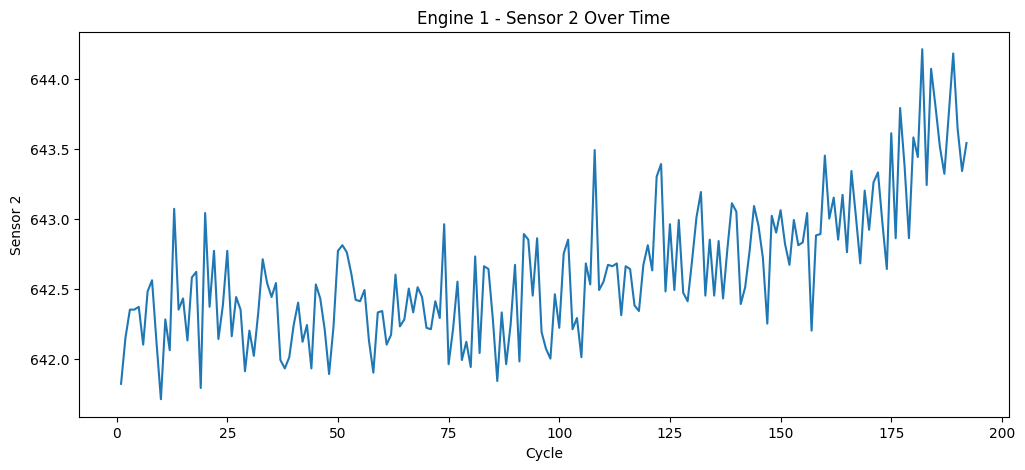

In [16]:
plt.figure(figsize=(12, 5))

engine_1 = train_df[train_df["unit_id"] == 1]

plt.plot(engine_1["cycle"], engine_1["sensor_2"])

plt.xlabel("Cycle")
plt.ylabel("Sensor 2")
plt.title("Engine 1 - Sensor 2 Over Time")

plt.show()

In [17]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]

train_df[sensor_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sensor_1,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200
sensor_6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
sensor_7,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600
sensor_8,20631.0,2388.096652,7.098548e-02,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600
sensor_9,20631.0,9065.242941,2.208288e+01,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
sensor_10,20631.0,1.300000,4.660829e-13,1.3000,1.3000,1.3000,1.3000,1.3000


In [18]:
sensor_std = train_df[sensor_cols].std()

constant_sensors = sensor_std[sensor_std < 1e-5]

print("Constant / near-constant sensors:")
print(constant_sensors)

Constant / near-constant sensors:
sensor_1     6.537152e-11
sensor_5     3.394700e-12
sensor_10    4.660829e-13
sensor_16    1.556432e-14
sensor_18    0.000000e+00
sensor_19    0.000000e+00
dtype: float64


In [19]:
print("Number of constant sensors:", len(constant_sensors))

Number of constant sensors: 6


In [20]:
sensor_std.sort_values(ascending=False)

,0
sensor_9,2.208288e+01
sensor_14,1.907618e+01
sensor_4,9.000605e+00
sensor_3,6.131150e+00
sensor_17,1.548763e+00
sensor_7,8.850923e-01
sensor_12,7.375534e-01
sensor_2,5.000533e-01
sensor_11,2.670874e-01
sensor_20,1.807464e-01


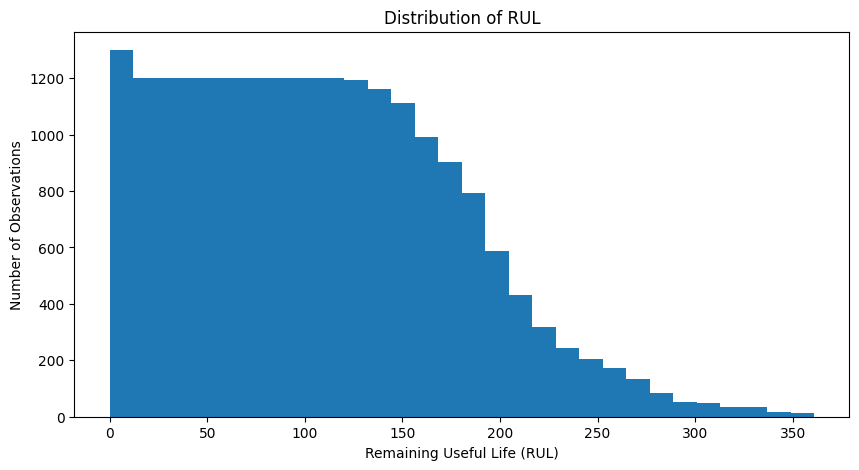

In [21]:
plt.figure(figsize=(10, 5))

plt.hist(train_df["RUL"], bins=30)

plt.xlabel("Remaining Useful Life (RUL)")
plt.ylabel("Number of Observations")
plt.title("Distribution of RUL")

plt.show()

In [22]:
correlation = train_df[sensor_cols + ["RUL"]].corr()["RUL"].drop("RUL")

correlation = correlation.sort_values()

print(correlation)

sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
sensor_14   -0.306769
sensor_6    -0.128348
sensor_20    0.629428
sensor_21    0.635662
sensor_7     0.657223
sensor_12    0.671983
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: RUL, dtype: float64


In [23]:
top_sensors = correlation.abs().sort_values(ascending=False).head(5).index

print("Top 5 sensors by absolute correlation with RUL:")
print(top_sensors)

Top 5 sensors by absolute correlation with RUL:
Index(['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15'], dtype='object')


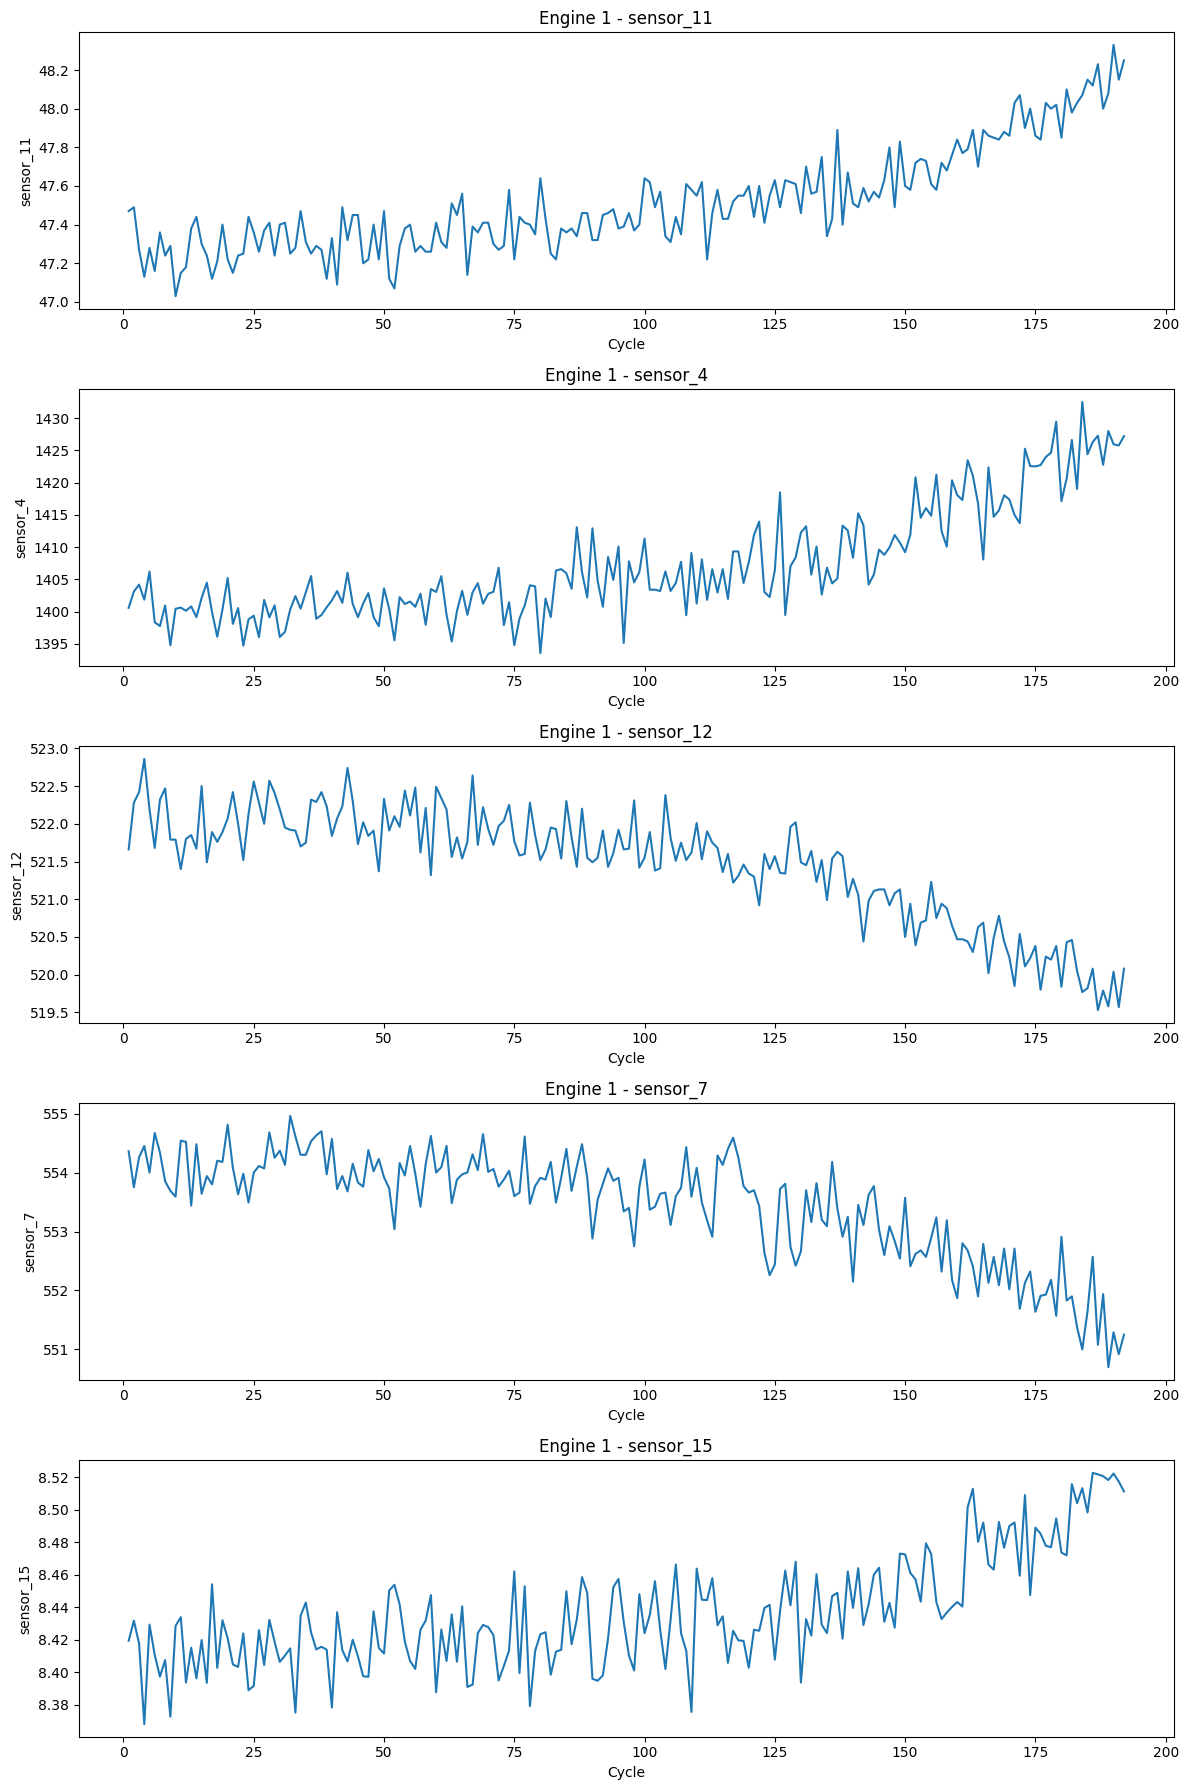

In [24]:
fig, axes = plt.subplots(5, 1, figsize=(12, 18))

for ax, sensor in zip(axes, top_sensors):
    ax.plot(engine_1["cycle"], engine_1[sensor])
    ax.set_title(f"Engine 1 - {sensor}")
    ax.set_xlabel("Cycle")
    ax.set_ylabel(sensor)

plt.tight_layout()
plt.show()

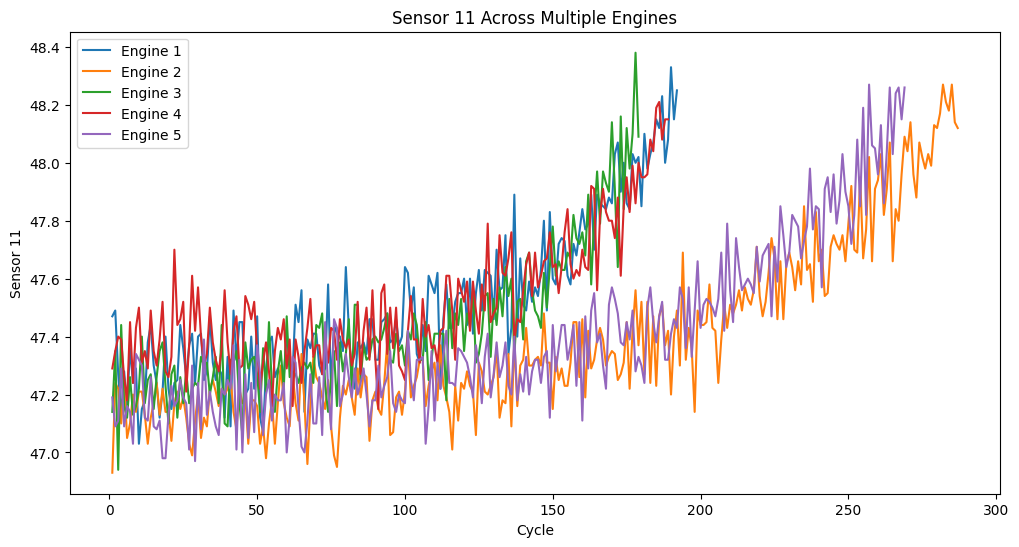

In [25]:
plt.figure(figsize=(12, 6))

for engine_id in [1, 2, 3, 4, 5]:
    engine_data = train_df[train_df["unit_id"] == engine_id]
    plt.plot(
        engine_data["cycle"],
        engine_data["sensor_11"],
        label=f"Engine {engine_id}"
    )

plt.xlabel("Cycle")
plt.ylabel("Sensor 11")
plt.title("Sensor 11 Across Multiple Engines")
plt.legend()
plt.show()

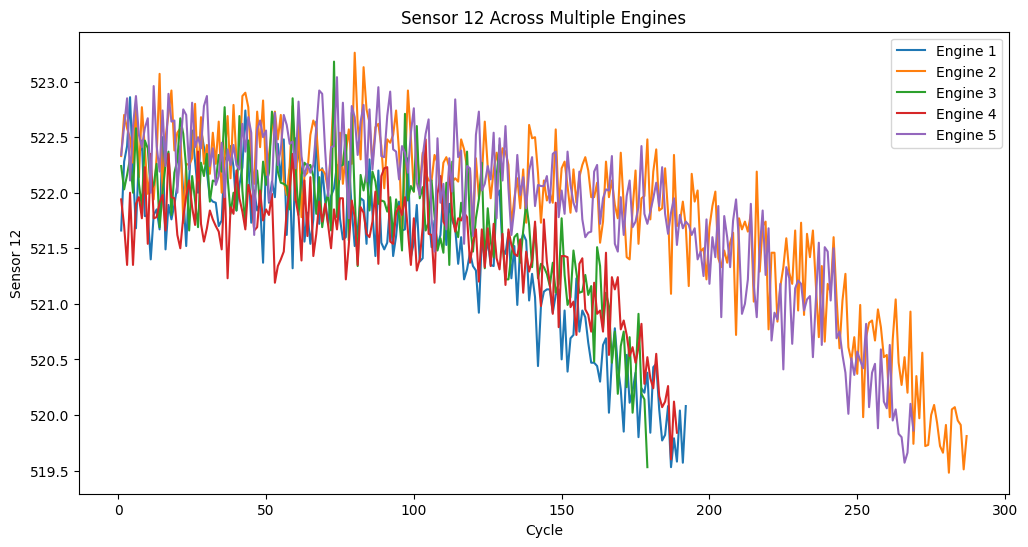

In [26]:
plt.figure(figsize=(12, 6))

for engine_id in [1, 2, 3, 4, 5]:
    engine_data = train_df[train_df["unit_id"] == engine_id]
    plt.plot(
        engine_data["cycle"],
        engine_data["sensor_12"],
        label=f"Engine {engine_id}"
    )

plt.xlabel("Cycle")
plt.ylabel("Sensor 12")
plt.title("Sensor 12 Across Multiple Engines")
plt.legend()
plt.show()

In [27]:
train_df["life_fraction"] = train_df["cycle"] / train_df["max_cycle"]

In [28]:
train_df[
    ["unit_id", "cycle", "max_cycle", "life_fraction"]
].head()

,unit_id,cycle,max_cycle,life_fraction
0,1,1,192,0.005208
1,1,2,192,0.010417
2,1,3,192,0.015625
3,1,4,192,0.020833
4,1,5,192,0.026042


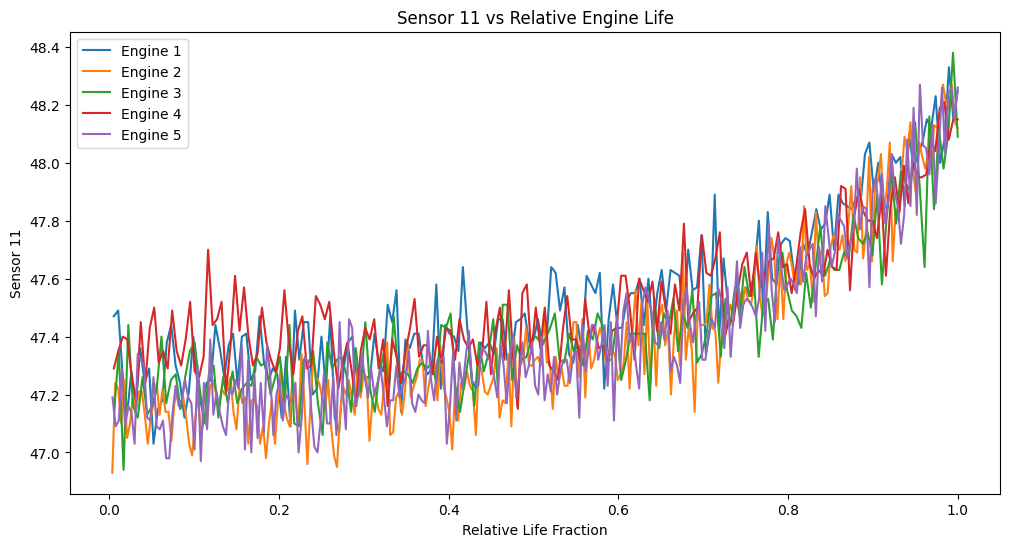

In [29]:
plt.figure(figsize=(12, 6))

for engine_id in [1, 2, 3, 4, 5]:
    engine_data = train_df[train_df["unit_id"] == engine_id]

    plt.plot(
        engine_data["life_fraction"],
        engine_data["sensor_11"],
        label=f"Engine {engine_id}"
    )

plt.xlabel("Relative Life Fraction")
plt.ylabel("Sensor 11")
plt.title("Sensor 11 vs Relative Engine Life")
plt.legend()
plt.show()

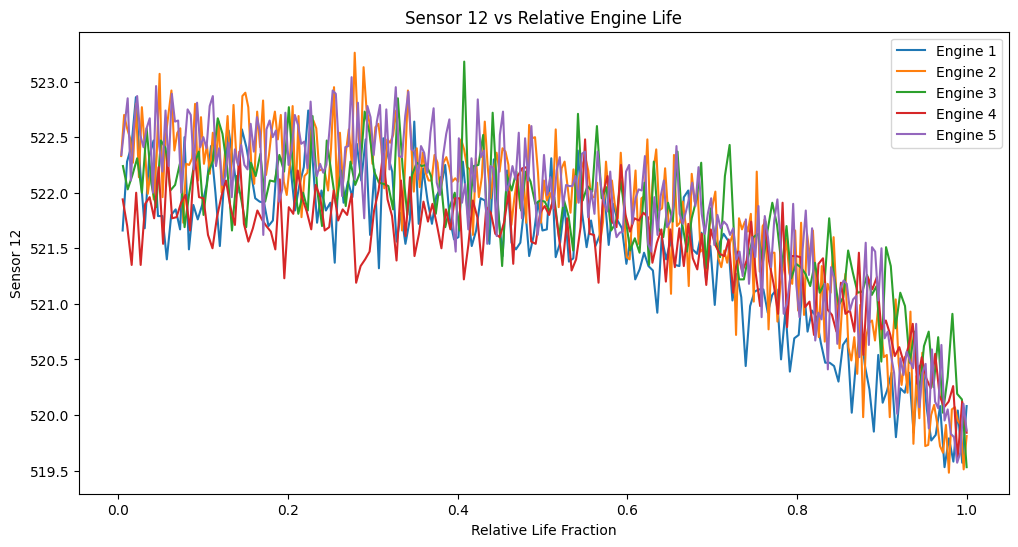

In [30]:
plt.figure(figsize=(12, 6))

for engine_id in [1, 2, 3, 4, 5]:
    engine_data = train_df[train_df["unit_id"] == engine_id]

    plt.plot(
        engine_data["life_fraction"],
        engine_data["sensor_12"],
        label=f"Engine {engine_id}"
    )

plt.xlabel("Relative Life Fraction")
plt.ylabel("Sensor 12")
plt.title("Sensor 12 vs Relative Engine Life")
plt.legend()
plt.show()

In [31]:
constant_sensor_names = constant_sensors.index.tolist()

selected_sensors = [
    sensor for sensor in sensor_cols
    if sensor not in constant_sensor_names
]

print("Removed sensors:")
print(constant_sensor_names)

print("\nRemaining sensors:")
print(selected_sensors)

print("\nNumber of remaining sensors:", len(selected_sensors))

Removed sensors:
['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Remaining sensors:
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

Number of remaining sensors: 15


In [32]:
train_df[selected_sensors].isnull().sum()

,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_6,0
sensor_7,0
sensor_8,0
sensor_9,0
sensor_11,0
sensor_12,0
sensor_13,0


In [33]:
print("Total missing values:", train_df.isnull().sum().sum())

Total missing values: 0


In [34]:
from sklearn.model_selection import train_test_split

In [35]:
# Get unique engine IDs
engine_ids = train_df["unit_id"].unique()

# Split engines, not individual rows
train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

print("Training engines:", len(train_engines))
print("Validation engines:", len(val_engines))

Training engines: 80
Validation engines: 20


In [36]:
train_data = train_df[
    train_df["unit_id"].isin(train_engines)
].copy()

val_data = train_df[
    train_df["unit_id"].isin(val_engines)
].copy()

print("Training rows:", train_data.shape)
print("Validation rows:", val_data.shape)

Training rows: (16561, 29)
Validation rows: (4070, 29)


In [37]:
print(
    "Common engines between train and validation:",
    len(
        set(train_data["unit_id"]) &
        set(val_data["unit_id"])
    )
)

Common engines between train and validation: 0


In [38]:
feature_cols = selected_sensors

X_train = train_data[feature_cols]
y_train = train_data["RUL"]

X_val = val_data[feature_cols]
y_val = val_data["RUL"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (16561, 15)
y_train: (16561,)
X_val: (4070, 15)
y_val: (4070,)


In [39]:
from sklearn.ensemble import RandomForestRegressor

In [40]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [41]:
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [42]:
y_pred = rf_model.predict(X_val)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[164.745 178.74  180.    201.565 169.    199.2   182.91  180.79  190.975
 198.89 ]


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [44]:
mae = mean_absolute_error(y_val, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_val, y_pred)
)

r2 = r2_score(y_val, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 25.86
RMSE : 35.35
R²   : 0.7101


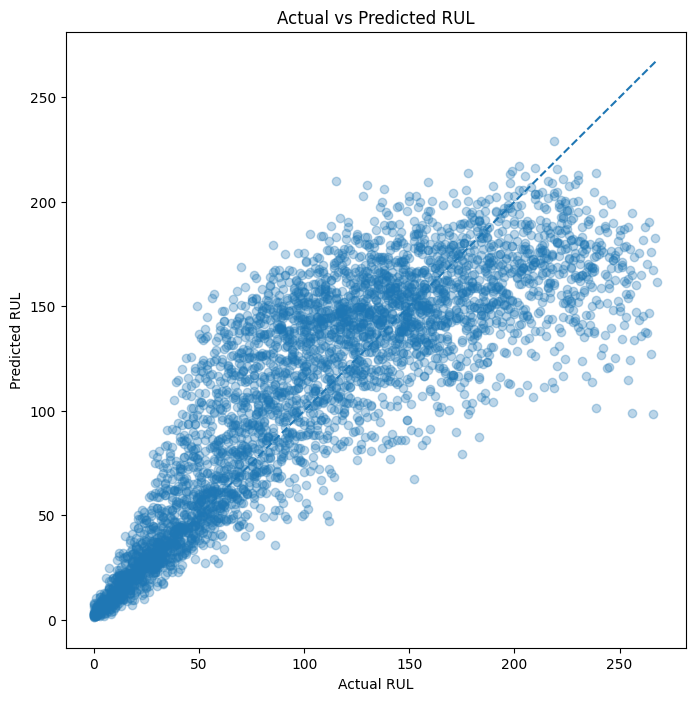

In [45]:
plt.figure(figsize=(8, 8))

plt.scatter(y_val, y_pred, alpha=0.3)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

# Perfect prediction line
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--"
)

plt.show()

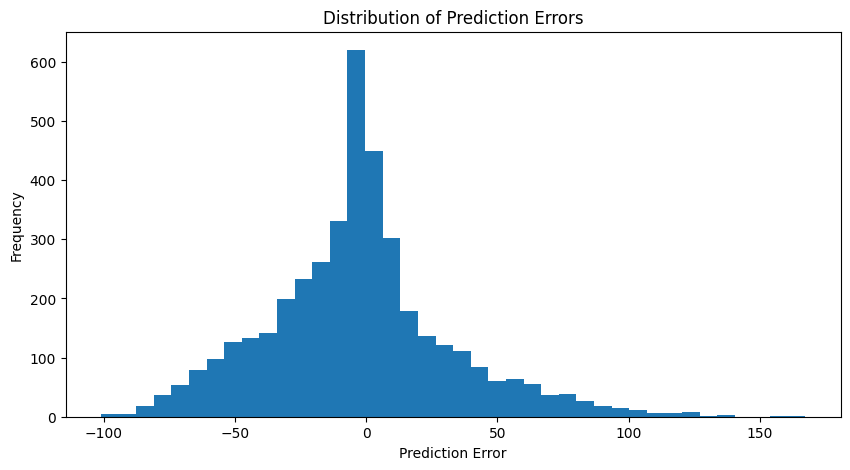

In [46]:
errors = y_val - y_pred

plt.figure(figsize=(10, 5))

plt.hist(errors, bins=40)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.show()

In [47]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print(feature_importance)

sensor_11    0.435758
sensor_9     0.129309
sensor_4     0.080291
sensor_12    0.048124
sensor_14    0.043702
sensor_7     0.040725
sensor_15    0.037672
sensor_21    0.035541
sensor_3     0.032735
sensor_2     0.031199
sensor_20    0.027262
sensor_13    0.022957
sensor_8     0.022952
sensor_17    0.011006
sensor_6     0.000765
dtype: float64


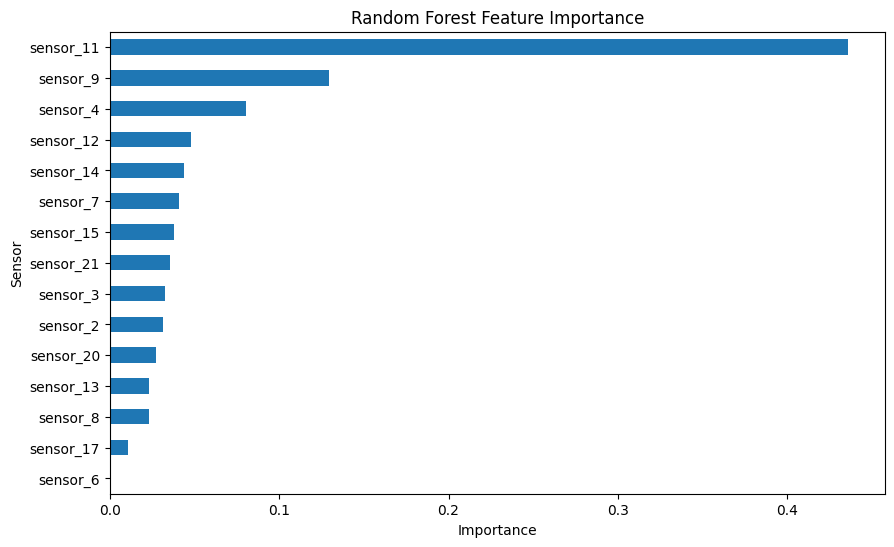

In [48]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Sensor")
plt.title("Random Forest Feature Importance")

plt.show()

In [49]:
model_df = train_df.copy()

In [50]:
rolling_sensors = selected_sensors

In [51]:
for sensor in rolling_sensors:
    model_df[f"{sensor}_roll_mean_10"] = (
        model_df.groupby("unit_id")[sensor]
        .transform(lambda x: x.rolling(window=10, min_periods=1).mean())
    )

    model_df[f"{sensor}_roll_std_10"] = (
        model_df.groupby("unit_id")[sensor]
        .transform(lambda x: x.rolling(window=10, min_periods=1).std())
    )

In [52]:
model_df.shape

(20631, 59)

In [53]:
feature_cols_temporal = (
    ["cycle"]
    + selected_sensors
    + [f"{sensor}_roll_mean_10" for sensor in rolling_sensors]
    + [f"{sensor}_roll_std_10" for sensor in rolling_sensors]
)

print("Number of features:", len(feature_cols_temporal))

Number of features: 46


In [54]:
model_df[feature_cols_temporal].isnull().sum().sort_values(ascending=False).head(10)

,0
sensor_4_roll_std_10,100
sensor_3_roll_std_10,100
sensor_8_roll_std_10,100
sensor_7_roll_std_10,100
sensor_9_roll_std_10,100
sensor_6_roll_std_10,100
sensor_15_roll_std_10,100
sensor_12_roll_std_10,100
sensor_13_roll_std_10,100
sensor_14_roll_std_10,100


In [55]:
print("Total missing values:",
      model_df[feature_cols_temporal].isnull().sum().sum())

Total missing values: 1500


In [56]:
model_df[feature_cols_temporal] = (
    model_df[feature_cols_temporal].fillna(0)
)

In [57]:
print(
    "Total missing values after filling:",
    model_df[feature_cols_temporal].isnull().sum().sum()
)

Total missing values after filling: 0


In [58]:
temporal_train = model_df[
    model_df["unit_id"].isin(train_engines)
].copy()

temporal_val = model_df[
    model_df["unit_id"].isin(val_engines)
].copy()

In [59]:
X_train_temporal = temporal_train[feature_cols_temporal]
y_train_temporal = temporal_train["RUL"]

X_val_temporal = temporal_val[feature_cols_temporal]
y_val_temporal = temporal_val["RUL"]

print("Training:", X_train_temporal.shape)
print("Validation:", X_val_temporal.shape)

Training: (16561, 46)
Validation: (4070, 46)


In [60]:
rf_temporal = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_temporal.fit(
    X_train_temporal,
    y_train_temporal
)

print("Temporal Random Forest training completed!")

Temporal Random Forest training completed!


In [61]:
y_pred_temporal = rf_temporal.predict(X_val_temporal)

In [62]:
mae_temporal = mean_absolute_error(
    y_val_temporal,
    y_pred_temporal
)

rmse_temporal = np.sqrt(
    mean_squared_error(y_val_temporal, y_pred_temporal)
)

r2_temporal = r2_score(
    y_val_temporal,
    y_pred_temporal
)

print(f"Temporal RF MAE  : {mae_temporal:.2f}")
print(f"Temporal RF RMSE : {rmse_temporal:.2f}")
print(f"Temporal RF R²   : {r2_temporal:.4f}")

Temporal RF MAE  : 24.20
Temporal RF RMSE : 32.87
Temporal RF R²   : 0.7493


In [63]:
temporal_importance = pd.Series(
    rf_temporal.feature_importances_,
    index=feature_cols_temporal
).sort_values(ascending=False)

print(temporal_importance.head(20))

cycle                     0.527118
sensor_15_roll_mean_10    0.091257
sensor_3_roll_mean_10     0.044119
sensor_14_roll_mean_10    0.034719
sensor_2_roll_mean_10     0.032080
sensor_9_roll_mean_10     0.027133
sensor_4_roll_mean_10     0.024012
sensor_8_roll_mean_10     0.015711
sensor_11_roll_mean_10    0.014883
sensor_13_roll_mean_10    0.014463
sensor_7_roll_mean_10     0.014203
sensor_12_roll_mean_10    0.013632
sensor_21_roll_mean_10    0.013046
sensor_20_roll_mean_10    0.008897
sensor_15_roll_std_10     0.008800
sensor_12_roll_std_10     0.008737
sensor_9_roll_std_10      0.008690
sensor_14_roll_std_10     0.007799
sensor_11_roll_std_10     0.007382
sensor_7_roll_std_10      0.007253
dtype: float64


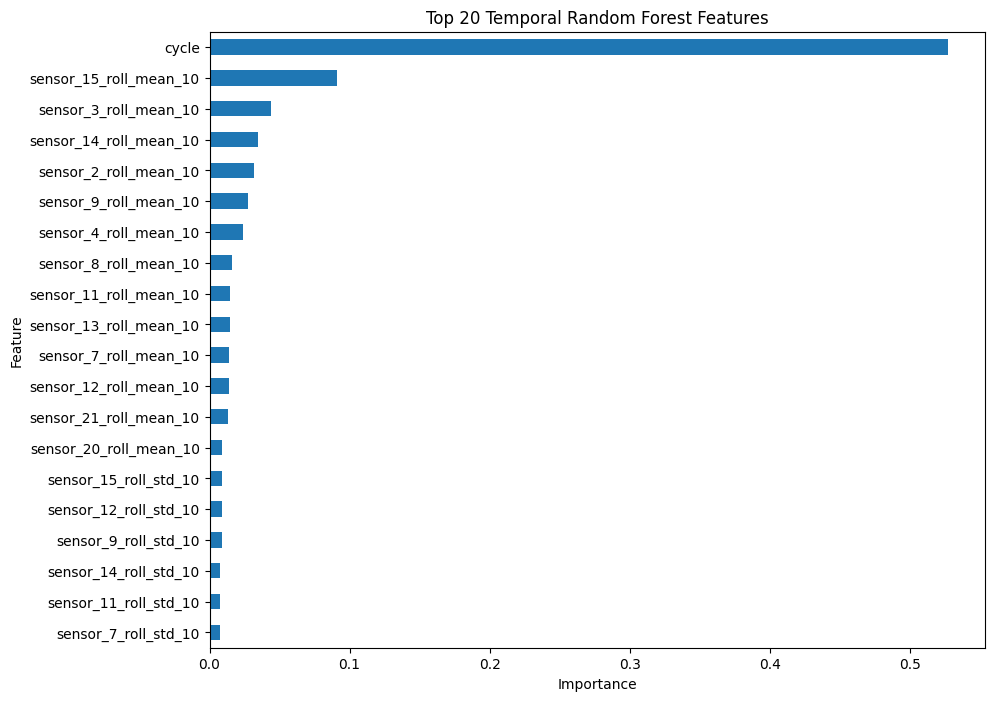

In [64]:
plt.figure(figsize=(10, 8))

temporal_importance.head(20).sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Temporal Random Forest Features")

plt.show()

In [65]:
feature_cols_no_cycle = (
    selected_sensors
    + [f"{sensor}_roll_mean_10" for sensor in rolling_sensors]
    + [f"{sensor}_roll_std_10" for sensor in rolling_sensors]
)

print("Features without cycle:", len(feature_cols_no_cycle))

Features without cycle: 45


In [66]:
X_train_no_cycle = temporal_train[feature_cols_no_cycle]
y_train_no_cycle = temporal_train["RUL"]

X_val_no_cycle = temporal_val[feature_cols_no_cycle]
y_val_no_cycle = temporal_val["RUL"]

In [67]:
rf_no_cycle = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_no_cycle.fit(
    X_train_no_cycle,
    y_train_no_cycle
)

y_pred_no_cycle = rf_no_cycle.predict(X_val_no_cycle)

In [68]:
mae_no_cycle = mean_absolute_error(
    y_val_no_cycle,
    y_pred_no_cycle
)

rmse_no_cycle = np.sqrt(
    mean_squared_error(y_val_no_cycle, y_pred_no_cycle)
)

r2_no_cycle = r2_score(
    y_val_no_cycle,
    y_pred_no_cycle
)

print(f"RF without cycle MAE  : {mae_no_cycle:.2f}")
print(f"RF without cycle RMSE : {rmse_no_cycle:.2f}")
print(f"RF without cycle R²   : {r2_no_cycle:.4f}")

RF without cycle MAE  : 24.67
RF without cycle RMSE : 34.92
RF without cycle R²   : 0.7172


In [69]:
results = pd.DataFrame({
    "Model": [
        "Random Forest - Baseline",
        "Random Forest - Temporal + Cycle",
        "Random Forest - Temporal without Cycle"
    ],
    "Features": [
        15,
        46,
        45
    ],
    "MAE": [
        mae,
        mae_temporal,
        mae_no_cycle
    ],
    "RMSE": [
        rmse,
        rmse_temporal,
        rmse_no_cycle
    ],
    "R2": [
        r2,
        r2_temporal,
        r2_no_cycle
    ]
})

results

,Model,Features,MAE,RMSE,R2
0,Random Forest - Baseline,15,25.861968,35.349116,0.710091
1,Random Forest - Temporal + Cycle,46,24.203093,32.869333,0.749339
2,Random Forest - Temporal without Cycle,45,24.668727,34.915494,0.717159


In [70]:
from xgboost import XGBRegressor

In [71]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [72]:
xgb_model.fit(
    X_train_temporal,
    y_train_temporal
)

print("XGBoost training completed!")

XGBoost training completed!


In [73]:
y_pred_xgb = xgb_model.predict(X_val_temporal)

In [74]:
mae_xgb = mean_absolute_error(
    y_val_temporal,
    y_pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(y_val_temporal, y_pred_xgb)
)

r2_xgb = r2_score(
    y_val_temporal,
    y_pred_xgb
)

print(f"XGBoost MAE  : {mae_xgb:.2f}")
print(f"XGBoost RMSE : {rmse_xgb:.2f}")
print(f"XGBoost R²   : {r2_xgb:.4f}")

XGBoost MAE  : 24.54
XGBoost RMSE : 33.42
XGBoost R²   : 0.7409


In [75]:
results.loc[len(results)] = [
    "XGBoost - Temporal + Cycle",
    46,
    mae_xgb,
    rmse_xgb,
    r2_xgb
]

results

,Model,Features,MAE,RMSE,R2
0,Random Forest - Baseline,15,25.861968,35.349116,0.710091
1,Random Forest - Temporal + Cycle,46,24.203093,32.869333,0.749339
2,Random Forest - Temporal without Cycle,45,24.668727,34.915494,0.717159
3,XGBoost - Temporal + Cycle,46,24.535295,33.421004,0.740854


In [76]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols_temporal
).sort_values(ascending=False)

print(xgb_importance.head(20))

cycle                     0.216530
sensor_15_roll_mean_10    0.106835
sensor_4_roll_mean_10     0.084530
sensor_21_roll_mean_10    0.063982
sensor_3_roll_mean_10     0.062953
sensor_2_roll_mean_10     0.058149
sensor_14_roll_mean_10    0.029503
sensor_9_roll_mean_10     0.024766
sensor_8_roll_mean_10     0.022738
sensor_11_roll_mean_10    0.022648
sensor_13_roll_mean_10    0.021099
sensor_7_roll_mean_10     0.021084
sensor_12_roll_mean_10    0.018635
sensor_17_roll_mean_10    0.013893
sensor_12_roll_std_10     0.013469
sensor_20_roll_mean_10    0.012551
sensor_17_roll_std_10     0.011934
sensor_9_roll_std_10      0.011841
sensor_15_roll_std_10     0.010999
sensor_11                 0.010817
dtype: float32


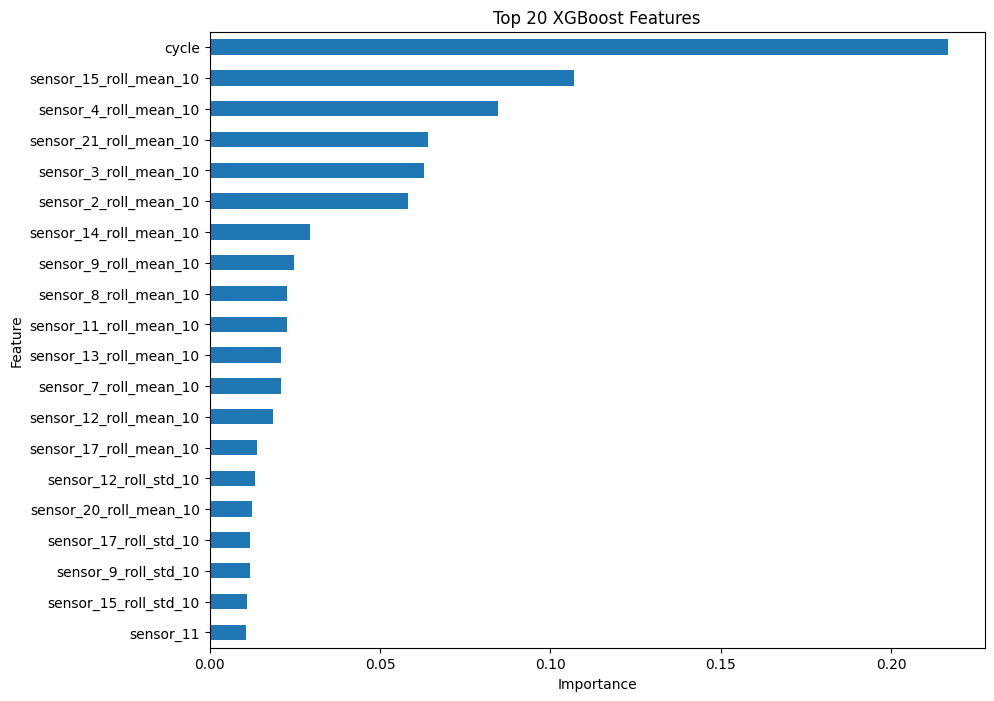

In [77]:
plt.figure(figsize=(10, 8))

xgb_importance.head(20).sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Features")

plt.show()

In [78]:
lstm_features = selected_sensors

print("LSTM features:", len(lstm_features))
print(lstm_features)

LSTM features: 15
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [79]:
from sklearn.preprocessing import StandardScaler

In [80]:
scaler = StandardScaler()

In [81]:
scaler.fit(
    train_data[lstm_features]
)

StandardScaler()

In [82]:
train_scaled = train_data.copy()
val_scaled = val_data.copy()

train_scaled[lstm_features] = scaler.transform(
    train_data[lstm_features]
)

val_scaled[lstm_features] = scaler.transform(
    val_data[lstm_features]
)

In [83]:
print("Training rows:", train_scaled.shape)
print("Validation rows:", val_scaled.shape)

Training rows: (16561, 29)
Validation rows: (4070, 29)


In [84]:
print("Number of LSTM features:", len(lstm_features))

Number of LSTM features: 15


In [85]:
SEQUENCE_LENGTH = 30

def create_sequences(data, features, sequence_length):
    X = []
    y = []

    # Process each engine separately
    for engine_id, engine_data in data.groupby("unit_id"):

        # Make sure cycles are chronological
        engine_data = engine_data.sort_values("cycle")

        sensor_values = engine_data[features].values
        rul_values = engine_data["RUL"].values

        # Create sliding windows
        for i in range(sequence_length, len(engine_data)):
            X.append(
                sensor_values[i-sequence_length:i]
            )

            y.append(
                rul_values[i]
            )

    return np.array(X), np.array(y)

In [86]:
X_train_lstm, y_train_lstm = create_sequences(
    train_scaled,
    lstm_features,
    SEQUENCE_LENGTH
)

print("X_train_lstm shape:", X_train_lstm.shape)
print("y_train_lstm shape:", y_train_lstm.shape)

X_train_lstm shape: (14161, 30, 15)
y_train_lstm shape: (14161,)


In [87]:
X_val_lstm, y_val_lstm = create_sequences(
    val_scaled,
    lstm_features,
    SEQUENCE_LENGTH
)

print("X_val_lstm shape:", X_val_lstm.shape)
print("y_val_lstm shape:", y_val_lstm.shape)

X_val_lstm shape: (3470, 30, 15)
y_val_lstm shape: (3470,)


In [88]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [89]:
lstm_model = Sequential([
    LSTM(64, input_shape=(SEQUENCE_LENGTH, len(lstm_features))),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,593 (88.25 KB)

 Trainable params: 22,593 (88.25 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [91]:
history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 7037.5752 - mae: 62.4112 - val_loss: 1804.6820 - val_mae: 29.6734
Epoch 2/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1692.9398 - mae: 27.7625 - val_loss: 878.1504 - val_mae: 21.1209
Epoch 3/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1312.0867 - mae: 24.5548 - val_loss: 700.0583 - val_mae: 18.8686
Epoch 4/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1094.7495 - mae: 22.4948 - val_loss: 622.8409 - val_mae: 17.8537
Epoch 5/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 992.0518 - mae: 21.3897 - val_loss: 564.5721 - val_mae: 17.2181
Epoch 6/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 919.7297 - mae: 20.7522 - val_loss: 555.9842 - val_mae: 16.8738
Epoch 7/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 867.2056 - mae: 20.1069 - val_loss: 674.4797 - val_mae: 18.3976
Epoch 8/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 819.7684 - mae: 19.4927 - val_loss: 714.3372 - val_mae: 18.8156
Ep

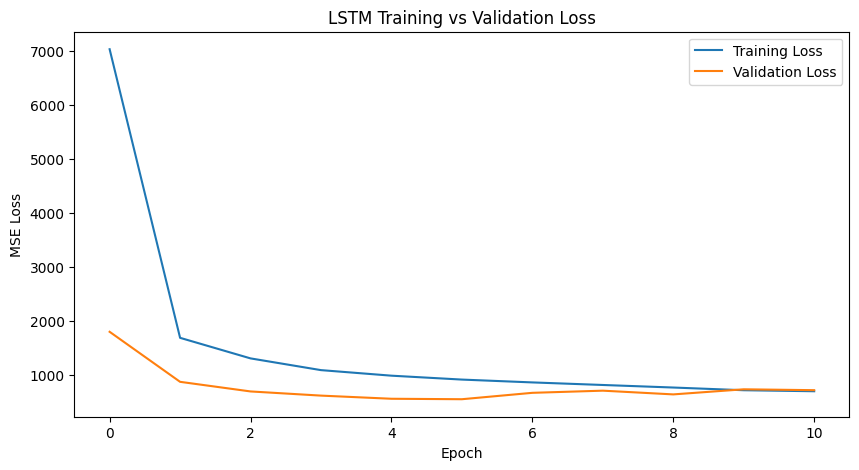

In [92]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()

plt.show()

In [93]:
y_pred_lstm = lstm_model.predict(
    X_val_lstm,
    verbose=0
).flatten()

print("Predictions shape:", y_pred_lstm.shape)

Predictions shape: (3470,)


In [94]:
mae_lstm = mean_absolute_error(
    y_val_lstm,
    y_pred_lstm
)

rmse_lstm = np.sqrt(
    mean_squared_error(y_val_lstm, y_pred_lstm)
)

r2_lstm = r2_score(
    y_val_lstm,
    y_pred_lstm
)

print(f"LSTM MAE  : {mae_lstm:.2f}")
print(f"LSTM RMSE : {rmse_lstm:.2f}")
print(f"LSTM R²   : {r2_lstm:.4f}")

LSTM MAE  : 16.87
LSTM RMSE : 23.58
LSTM R²   : 0.8347


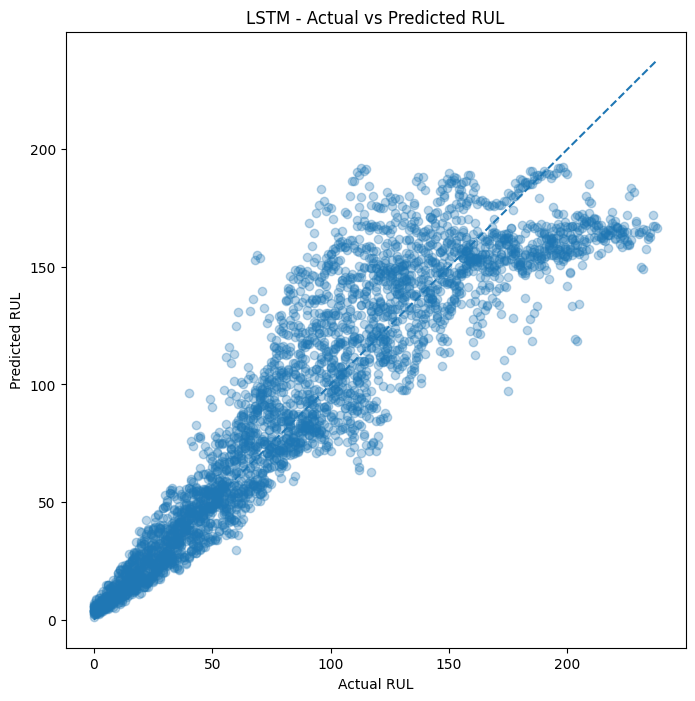

In [95]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_val_lstm,
    y_pred_lstm,
    alpha=0.3
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("LSTM - Actual vs Predicted RUL")

plt.plot(
    [y_val_lstm.min(), y_val_lstm.max()],
    [y_val_lstm.min(), y_val_lstm.max()],
    linestyle="--"
)

plt.show()

In [96]:
fair_val = model_df[
    (model_df["unit_id"].isin(val_engines)) &
    (model_df["cycle"] > SEQUENCE_LENGTH)
].copy()

print("Fair validation shape:", fair_val.shape)

Fair validation shape: (3470, 59)


In [97]:
X_fair_rf = fair_val[feature_cols_temporal]
y_fair = fair_val["RUL"]

y_pred_rf_fair = rf_temporal.predict(X_fair_rf)

mae_rf_fair = mean_absolute_error(
    y_fair,
    y_pred_rf_fair
)

rmse_rf_fair = np.sqrt(
    mean_squared_error(y_fair, y_pred_rf_fair)
)

r2_rf_fair = r2_score(
    y_fair,
    y_pred_rf_fair
)

print(f"Fair RF MAE  : {mae_rf_fair:.2f}")
print(f"Fair RF RMSE : {rmse_rf_fair:.2f}")
print(f"Fair RF R²   : {r2_rf_fair:.4f}")

Fair RF MAE  : 21.80
Fair RF RMSE : 30.37
Fair RF R²   : 0.7259


In [98]:
X_fair_xgb = fair_val[feature_cols_temporal]

y_pred_xgb_fair = xgb_model.predict(X_fair_xgb)

mae_xgb_fair = mean_absolute_error(
    y_fair,
    y_pred_xgb_fair
)

rmse_xgb_fair = np.sqrt(
    mean_squared_error(y_fair, y_pred_xgb_fair)
)

r2_xgb_fair = r2_score(
    y_fair,
    y_pred_xgb_fair
)

print(f"Fair XGB MAE  : {mae_xgb_fair:.2f}")
print(f"Fair XGB RMSE : {rmse_xgb_fair:.2f}")
print(f"Fair XGB R²   : {r2_xgb_fair:.4f}")

Fair XGB MAE  : 22.25
Fair XGB RMSE : 30.91
Fair XGB R²   : 0.7159


In [99]:
X_fair_baseline = fair_val[selected_sensors]
y_fair_baseline = fair_val["RUL"]

y_pred_baseline_fair = rf_model.predict(X_fair_baseline)

mae_baseline_fair = mean_absolute_error(
    y_fair_baseline,
    y_pred_baseline_fair
)

rmse_baseline_fair = np.sqrt(
    mean_squared_error(y_fair_baseline, y_pred_baseline_fair)
)

r2_baseline_fair = r2_score(
    y_fair_baseline,
    y_pred_baseline_fair
)

print(f"Fair Baseline RF MAE  : {mae_baseline_fair:.2f}")
print(f"Fair Baseline RF RMSE : {rmse_baseline_fair:.2f}")
print(f"Fair Baseline RF R²   : {r2_baseline_fair:.4f}")

Fair Baseline RF MAE  : 23.45
Fair Baseline RF RMSE : 31.93
Fair Baseline RF R²   : 0.6969


In [100]:
lstm_errors = y_val_lstm - y_pred_lstm

print("Mean error:", np.mean(lstm_errors))
print("Max absolute error:", np.max(np.abs(lstm_errors)))
print("MAE:", mean_absolute_error(y_val_lstm, y_pred_lstm))

Mean error: -1.7275183189155732
Max absolute error: 86.85801696777344
MAE: 16.873823165893555


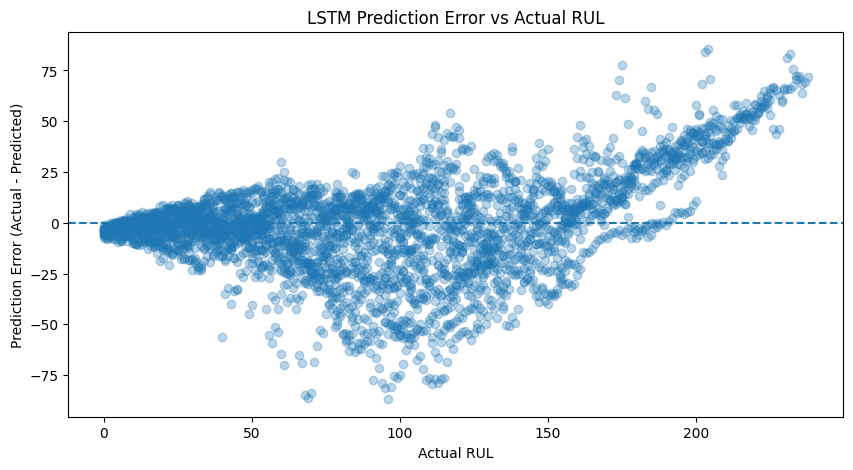

In [101]:
plt.figure(figsize=(10, 5))

plt.scatter(
    y_val_lstm,
    lstm_errors,
    alpha=0.3
)

plt.axhline(0, linestyle="--")

plt.xlabel("Actual RUL")
plt.ylabel("Prediction Error (Actual - Predicted)")
plt.title("LSTM Prediction Error vs Actual RUL")

plt.show()

In [102]:
SEQUENCE_LENGTH_50 = 50

X_train_lstm_50, y_train_lstm_50 = create_sequences(
    train_scaled,
    lstm_features,
    SEQUENCE_LENGTH_50
)

X_val_lstm_50, y_val_lstm_50 = create_sequences(
    val_scaled,
    lstm_features,
    SEQUENCE_LENGTH_50
)

print("X_train_lstm_50:", X_train_lstm_50.shape)
print("y_train_lstm_50:", y_train_lstm_50.shape)

print("X_val_lstm_50:", X_val_lstm_50.shape)
print("y_val_lstm_50:", y_val_lstm_50.shape)

X_train_lstm_50: (12561, 50, 15)
y_train_lstm_50: (12561,)
X_val_lstm_50: (3070, 50, 15)
y_val_lstm_50: (3070,)


In [103]:
lstm_model_50 = Sequential([
    LSTM(
        64,
        input_shape=(SEQUENCE_LENGTH_50, len(lstm_features))
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model_50.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model_50.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,593 (88.25 KB)

 Trainable params: 22,593 (88.25 KB)

 Non-trainable params: 0 (0.00 B)

In [104]:
early_stopping_50 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [105]:
history_50 = lstm_model_50.fit(
    X_train_lstm_50,
    y_train_lstm_50,
    validation_data=(
        X_val_lstm_50,
        y_val_lstm_50
    ),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping_50],
    verbose=1
)

Epoch 1/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 4720.9087 - mae: 49.2506 - val_loss: 898.7321 - val_mae: 21.8109
Epoch 2/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1270.0587 - mae: 24.4986 - val_loss: 567.3079 - val_mae: 17.5050
Epoch 3/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 948.6977 - mae: 20.6170 - val_loss: 386.5119 - val_mae: 13.6358
Epoch 4/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 756.7382 - mae: 18.6144 - val_loss: 449.7095 - val_mae: 14.6498
Epoch 5/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 668.4187 - mae: 17.4292 - val_loss: 459.8464 - val_mae: 14.8149
Epoch 6/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 578.5571 - mae: 16.3868 - val_loss: 460.7612 - val_mae: 14.8930
Epoch 7/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 537.1288 - mae: 15.5715 - val_loss: 560.6213 - val_mae: 15.8855
Epoch 8/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 506.6120 - mae: 15.0189 - val_loss: 613.0771 - val_mae: 17.3269


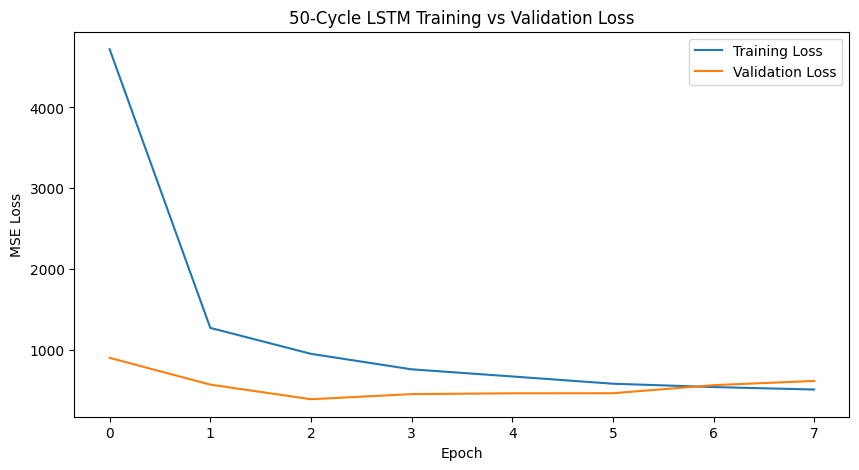

In [106]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_50.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_50.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("50-Cycle LSTM Training vs Validation Loss")
plt.legend()

plt.show()

In [107]:
y_pred_lstm_50 = lstm_model_50.predict(
    X_val_lstm_50,
    verbose=0
).flatten()

print("Predictions shape:", y_pred_lstm_50.shape)

Predictions shape: (3070,)


In [108]:
mae_lstm_50 = mean_absolute_error(
    y_val_lstm_50,
    y_pred_lstm_50
)

rmse_lstm_50 = np.sqrt(
    mean_squared_error(
        y_val_lstm_50,
        y_pred_lstm_50
    )
)

r2_lstm_50 = r2_score(
    y_val_lstm_50,
    y_pred_lstm_50
)

print(f"50-Cycle LSTM MAE  : {mae_lstm_50:.2f}")
print(f"50-Cycle LSTM RMSE : {rmse_lstm_50:.2f}")
print(f"50-Cycle LSTM R²   : {r2_lstm_50:.4f}")

50-Cycle LSTM MAE  : 13.64
50-Cycle LSTM RMSE : 19.66
50-Cycle LSTM R²   : 0.8626


In [109]:
fair_val_50 = model_df[
    (model_df["unit_id"].isin(val_engines)) &
    (model_df["cycle"] > SEQUENCE_LENGTH_50)
].copy()

print("Fair 50-cycle validation shape:", fair_val_50.shape)

Fair 50-cycle validation shape: (3070, 59)


In [110]:
X_fair_rf_50 = fair_val_50[feature_cols_temporal]
y_fair_50 = fair_val_50["RUL"]

y_pred_rf_50 = rf_temporal.predict(X_fair_rf_50)

print(
    f"RF MAE  : {mean_absolute_error(y_fair_50, y_pred_rf_50):.2f}"
)

print(
    f"RF RMSE : {np.sqrt(mean_squared_error(y_fair_50, y_pred_rf_50)):.2f}"
)

print(
    f"RF R²   : {r2_score(y_fair_50, y_pred_rf_50):.4f}"
)

RF MAE  : 19.73
RF RMSE : 27.71
RF R²   : 0.7272


In [111]:
X_fair_xgb_50 = fair_val_50[feature_cols_temporal]

y_pred_xgb_50 = xgb_model.predict(X_fair_xgb_50)

print(
    f"XGB MAE  : {mean_absolute_error(y_fair_50, y_pred_xgb_50):.2f}"
)

print(
    f"XGB RMSE : {np.sqrt(mean_squared_error(y_fair_50, y_pred_xgb_50)):.2f}"
)

print(
    f"XGB R²   : {r2_score(y_fair_50, y_pred_xgb_50):.4f}"
)

XGB MAE  : 20.22
XGB RMSE : 28.29
XGB R²   : 0.7156


In [112]:
import os

print(os.listdir("CMAPSSData"))

['readme.txt', 'RUL_FD002.txt', 'test_FD004.txt', 'train_FD003.txt', 'RUL_FD004.txt', 'Damage Propagation Modeling.pdf', 'RUL_FD001.txt', 'RUL_FD003.txt', 'test_FD003.txt', 'train_FD004.txt', 'test_FD001.txt', 'train_FD002.txt', 'train_FD001.txt', 'test_FD002.txt']


In [113]:
test_path = "CMAPSSData/test_FD001.txt"
rul_path = "CMAPSSData/RUL_FD001.txt"

test_df = pd.read_csv(
    test_path,
    sep=r"\s+",
    header=None
)

test_rul = pd.read_csv(
    rul_path,
    header=None
)

print("Test shape:", test_df.shape)
print("RUL shape:", test_rul.shape)

Test shape: (13096, 26)
RUL shape: (100, 1)


In [114]:
columns = [
    "unit_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
] + [f"sensor_{i}" for i in range(1, 22)]

test_df.columns = columns

print(test_df.head())

   unit_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0        1      1        0.0023        0.0003         100.0    518.67   
1        1      2       -0.0027       -0.0003         100.0    518.67   
2        1      3        0.0003        0.0001         100.0    518.67   
3        1      4        0.0042        0.0000         100.0    518.67   
4        1      5        0.0014        0.0000         100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
0    643.02   1585.29   1398.21     14.62  ...     521.72    2388.03   
1    641.71   1588.45   1395.42     14.62  ...     522.16    2388.06   
2    642.46   1586.94   1401.34     14.62  ...     521.97    2388.03   
3    642.44   1584.12   1406.42     14.62  ...     521.38    2388.05   
4    642.51   1587.19   1401.92     14.62  ...     522.15    2388.03   

   sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  \
0    8125.55     8.4052       0.03        392       2388 

In [115]:
print("Number of test engines:", test_df["unit_id"].nunique())

print(
    test_df.groupby("unit_id")["cycle"]
    .max()
    .head(10)
)

print("RUL values:", test_rul.shape)

Number of test engines: 100
unit_id
1      31
2      49
3     126
4     106
5      98
6     105
7     160
8     166
9      55
10    192
Name: cycle, dtype: int64
RUL values: (100, 1)


In [116]:
test_rul_values = test_rul[0].values

test_max_cycles = (
    test_df.groupby("unit_id")["cycle"]
    .max()
    .sort_index()
)

test_df["max_cycle"] = test_df["unit_id"].map(
    test_max_cycles
)

test_df["final_rul"] = test_df["unit_id"].map(
    dict(enumerate(test_rul_values, start=1))
)

test_df["RUL"] = (
    test_df["final_rul"]
    + test_df["max_cycle"]
    - test_df["cycle"]
)

print(
    test_df[
        ["unit_id", "cycle", "max_cycle", "final_rul", "RUL"]
    ].head(10)
)

   unit_id  cycle  max_cycle  final_rul  RUL
0        1      1         31        112  142
1        1      2         31        112  141
2        1      3         31        112  140
3        1      4         31        112  139
4        1      5         31        112  138
5        1      6         31        112  137
6        1      7         31        112  136
7        1      8         31        112  135
8        1      9         31        112  134
9        1     10         31        112  133


In [117]:
print(
    test_df.groupby("unit_id")["RUL"]
    .agg(["min", "max"])
    .head(10)
)

         min  max
unit_id          
1        112  142
2         98  146
3         69  194
4         82  187
5         91  188
6         93  197
7         91  250
8         95  260
9        111  165
10        96  287


In [118]:
print(
    test_df[
        test_df["unit_id"] == 1
    ][
        ["unit_id", "cycle", "max_cycle", "final_rul", "RUL"]
    ].tail()
)

    unit_id  cycle  max_cycle  final_rul  RUL
26        1     27         31        112  116
27        1     28         31        112  115
28        1     29         31        112  114
29        1     30         31        112  113
30        1     31         31        112  112


In [119]:
test_scaled = test_df.copy()

test_scaled[lstm_features] = scaler.transform(
    test_df[lstm_features]
)

print("Test scaled shape:", test_scaled.shape)

Test scaled shape: (13096, 29)


In [120]:
X_test_lstm_50, y_test_lstm_50 = create_sequences(
    test_scaled,
    lstm_features,
    SEQUENCE_LENGTH_50
)

print("X_test_lstm_50 shape:", X_test_lstm_50.shape)
print("y_test_lstm_50 shape:", y_test_lstm_50.shape)

X_test_lstm_50 shape: (8162, 50, 15)
y_test_lstm_50 shape: (8162,)


In [121]:
y_pred_test_lstm_50 = lstm_model_50.predict(
    X_test_lstm_50,
    verbose=0
).flatten()

print(
    "Test predictions shape:",
    y_pred_test_lstm_50.shape
)

Test predictions shape: (8162,)


In [122]:
len(y_test_lstm_50)

8162

In [123]:
mae_test = mean_absolute_error(
    y_test_lstm_50,
    y_pred_test_lstm_50
)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test_lstm_50,
        y_pred_test_lstm_50
    )
)

r2_test = r2_score(
    y_test_lstm_50,
    y_pred_test_lstm_50
)

print(f"FINAL TEST MAE  : {mae_test:.2f}")
print(f"FINAL TEST RMSE : {rmse_test:.2f}")
print(f"FINAL TEST R²   : {r2_test:.4f}")

FINAL TEST MAE  : 24.81
FINAL TEST RMSE : 35.42
FINAL TEST R²   : 0.5376


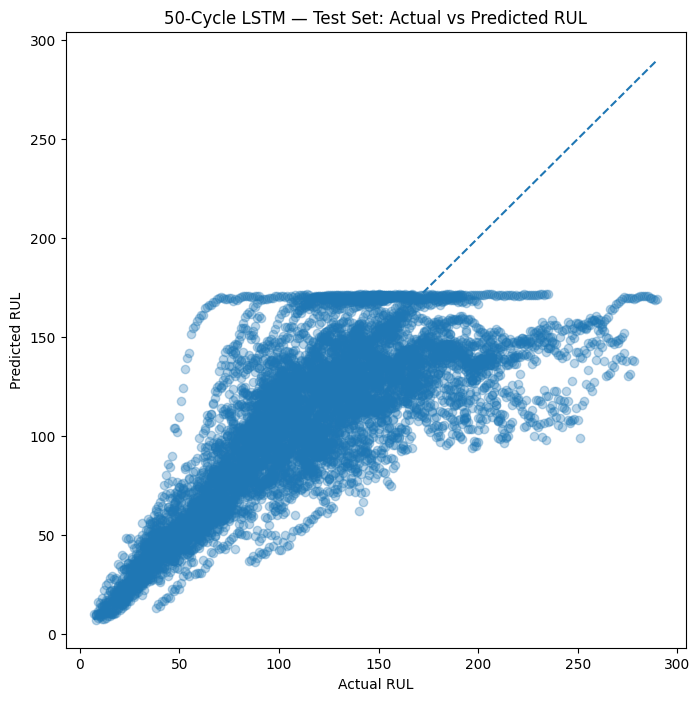

In [124]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test_lstm_50,
    y_pred_test_lstm_50,
    alpha=0.3
)

min_val = min(
    y_test_lstm_50.min(),
    y_pred_test_lstm_50.min()
)

max_val = max(
    y_test_lstm_50.max(),
    y_pred_test_lstm_50.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("50-Cycle LSTM — Test Set: Actual vs Predicted RUL")

plt.show()

In [125]:
print("TRAIN RUL")
print(train_df["RUL"].describe())

print("\nTEST RUL")
print(pd.Series(y_test_lstm_50).describe())

print("\nPREDICTED TEST RUL")
print(pd.Series(y_pred_test_lstm_50).describe())

TRAIN RUL
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64

TEST RUL
count    8162.000000
mean      116.657804
std        52.098082
min         7.000000
25%        80.000000
50%       115.000000
75%       149.000000
max       290.000000
dtype: float64

PREDICTED TEST RUL
count    8162.000000
mean      107.354279
std        39.733261
min         7.018145
25%        79.708054
50%       113.505211
75%       137.472279
max       171.695908
dtype: float64


In [126]:
test_errors = y_test_lstm_50 - y_pred_test_lstm_50

print("\nTEST ERROR")
print(pd.Series(test_errors).describe())

print("\nMean test error:", test_errors.mean())


TEST ERROR
count    8162.000000
mean        9.303525
std        34.181803
min      -101.708755
25%       -10.188822
50%         3.498093
75%        25.388331
max       152.255699
dtype: float64

Mean test error: 9.303525229874442


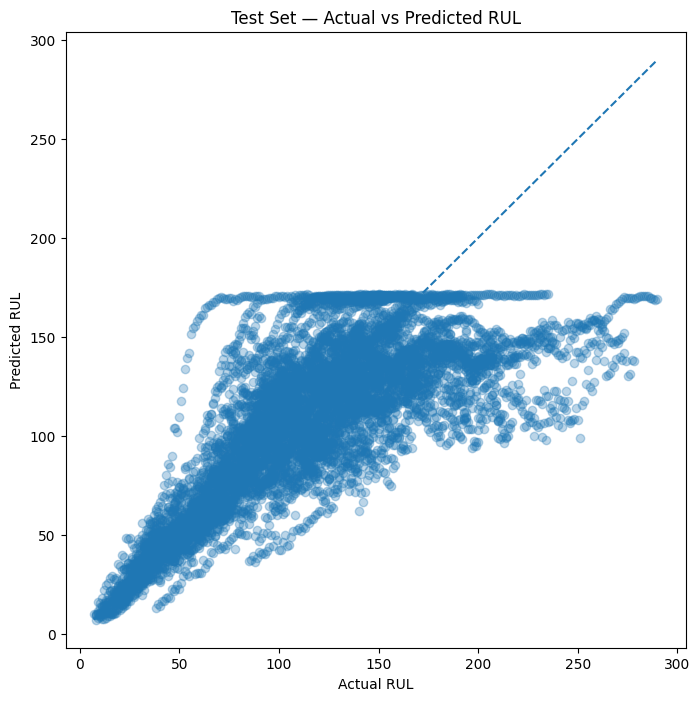

In [127]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test_lstm_50,
    y_pred_test_lstm_50,
    alpha=0.3
)

min_val = min(
    y_test_lstm_50.min(),
    y_pred_test_lstm_50.min()
)

max_val = max(
    y_test_lstm_50.max(),
    y_pred_test_lstm_50.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Test Set — Actual vs Predicted RUL")

plt.show()

In [128]:
test_analysis = pd.DataFrame({
    "actual_rul": y_test_lstm_50,
    "predicted_rul": y_pred_test_lstm_50
})

test_analysis["error"] = (
    test_analysis["actual_rul"]
    - test_analysis["predicted_rul"]
)

test_analysis["abs_error"] = (
    test_analysis["error"].abs()
)

test_analysis["rul_range"] = pd.cut(
    test_analysis["actual_rul"],
    bins=[0, 50, 100, 150, 200, 250, 300],
    labels=[
        "0-50",
        "51-100",
        "101-150",
        "151-200",
        "201-250",
        "251-300"
    ]
)

test_analysis.groupby("rul_range", observed=True).agg(
    samples=("actual_rul", "count"),
    MAE=("abs_error", "mean"),
    mean_error=("error", "mean")
)

,samples,MAE,mean_error
rul_range,,,
0-50,886,7.256811,-3.117164
51-100,2277,17.286970,-9.190840
101-150,3040,20.282567,2.459696
151-200,1447,34.207804,32.200686
201-250,409,82.637718,82.637718
251-300,103,114.116770,114.116770


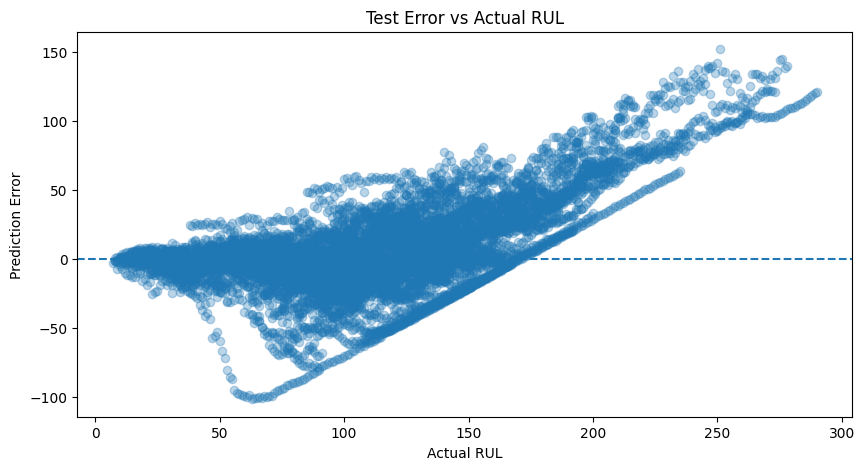

In [129]:
plt.figure(figsize=(10, 5))

plt.scatter(
    test_analysis["actual_rul"],
    test_analysis["error"],
    alpha=0.3
)

plt.axhline(0, linestyle="--")

plt.xlabel("Actual RUL")
plt.ylabel("Prediction Error")
plt.title("Test Error vs Actual RUL")

plt.show()

In [130]:
RUL_CAP = 125

train_df["RUL_capped"] = train_df["RUL"].clip(upper=RUL_CAP)
val_data["RUL_capped"] = val_data["RUL"].clip(upper=RUL_CAP)

print("Original max RUL:", train_df["RUL"].max())
print("Capped max RUL:", train_df["RUL_capped"].max())

Original max RUL: 361
Capped max RUL: 125


In [131]:
def create_sequences(
    data,
    features,
    sequence_length,
    target_col="RUL"
):
    X = []
    y = []

    for engine_id, engine_data in data.groupby("unit_id"):

        engine_data = engine_data.sort_values("cycle")

        sensor_values = engine_data[features].values
        target_values = engine_data[target_col].values

        for i in range(sequence_length, len(engine_data)):

            X.append(
                sensor_values[i-sequence_length:i]
            )

            y.append(
                target_values[i]
            )

    return np.array(X), np.array(y)

In [132]:
SEQUENCE_LENGTH_50 = 50

X_train_lstm_50_cap, y_train_lstm_50_cap = create_sequences(
    train_df[
        train_df["unit_id"].isin(train_engines)
    ],
    lstm_features,
    SEQUENCE_LENGTH_50,
    target_col="RUL_capped"
)

X_val_lstm_50_cap, y_val_lstm_50_cap = create_sequences(
    val_data,
    lstm_features,
    SEQUENCE_LENGTH_50,
    target_col="RUL_capped"
)

print("Training:", X_train_lstm_50_cap.shape)
print("Validation:", X_val_lstm_50_cap.shape)

Training: (12561, 50, 15)
Validation: (3070, 50, 15)


In [133]:
lstm_model_50_cap = Sequential([
    LSTM(
        64,
        input_shape=(SEQUENCE_LENGTH_50, len(lstm_features))
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model_50_cap.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model_50_cap.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,593 (88.25 KB)

 Trainable params: 22,593 (88.25 KB)

 Non-trainable params: 0 (0.00 B)

In [134]:
early_stopping_cap = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [135]:
history_50_cap = lstm_model_50_cap.fit(
    X_train_lstm_50_cap,
    y_train_lstm_50_cap,
    validation_data=(
        X_val_lstm_50_cap,
        y_val_lstm_50_cap
    ),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping_cap],
    verbose=1
)

Epoch 1/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5669.8301 - mae: 63.9585 - val_loss: 3336.7961 - val_mae: 48.0857
Epoch 2/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2294.7156 - mae: 40.9600 - val_loss: 1717.3553 - val_mae: 36.5580
Epoch 3/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1777.9937 - mae: 37.0045 - val_loss: 1700.7344 - val_mae: 36.3368
Epoch 4/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1780.9562 - mae: 37.0063 - val_loss: 1700.7107 - val_mae: 36.3403
Epoch 5/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1771.4532 - mae: 36.9056 - val_loss: 1700.9661 - val_mae: 36.3288
Epoch 6/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1795.1943 - mae: 37.1729 - val_loss: 1700.7731 - val_mae: 36.3346
Epoch 7/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1775.1122 - mae: 36.9588 - val_loss: 1701.1135 - val_mae: 36.3259
Epoch 8/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1789.5787 - mae: 37.0844 - val_loss: 1700.7146 - val_mae:

In [136]:
RUL_CAP = 125

train_scaled["RUL_capped"] = train_scaled["RUL"].clip(
    upper=RUL_CAP
)

val_scaled["RUL_capped"] = val_scaled["RUL"].clip(
    upper=RUL_CAP
)

print("Train capped max:", train_scaled["RUL_capped"].max())
print("Validation capped max:", val_scaled["RUL_capped"].max())

Train capped max: 125
Validation capped max: 125


In [137]:
X_train_lstm_50_cap, y_train_lstm_50_cap = create_sequences(
    train_scaled,
    lstm_features,
    SEQUENCE_LENGTH_50,
    target_col="RUL_capped"
)

X_val_lstm_50_cap, y_val_lstm_50_cap = create_sequences(
    val_scaled,
    lstm_features,
    SEQUENCE_LENGTH_50,
    target_col="RUL_capped"
)

print("X_train:", X_train_lstm_50_cap.shape)
print("y_train:", y_train_lstm_50_cap.shape)

print("X_val:", X_val_lstm_50_cap.shape)
print("y_val:", y_val_lstm_50_cap.shape)

X_train: (12561, 50, 15)
y_train: (12561,)
X_val: (3070, 50, 15)
y_val: (3070,)


In [138]:
lstm_model_50_cap = Sequential([
    LSTM(
        64,
        input_shape=(SEQUENCE_LENGTH_50, len(lstm_features))
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model_50_cap.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model_50_cap.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,593 (88.25 KB)

 Trainable params: 22,593 (88.25 KB)

 Non-trainable params: 0 (0.00 B)

In [139]:
early_stopping_cap = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_50_cap = lstm_model_50_cap.fit(
    X_train_lstm_50_cap,
    y_train_lstm_50_cap,
    validation_data=(
        X_val_lstm_50_cap,
        y_val_lstm_50_cap
    ),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping_cap],
    verbose=1
)

Epoch 1/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 3297.7932 - mae: 44.7593 - val_loss: 488.7290 - val_mae: 17.7105
Epoch 2/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 413.5960 - mae: 16.1895 - val_loss: 218.8563 - val_mae: 11.8828
Epoch 3/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 258.5780 - mae: 12.3483 - val_loss: 140.3314 - val_mae: 9.0940
Epoch 4/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 188.4882 - mae: 10.2262 - val_loss: 131.4824 - val_mae: 8.8429
Epoch 5/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 169.0611 - mae: 9.6465 - val_loss: 133.6485 - val_mae: 8.4617
Epoch 6/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 156.9626 - mae: 9.2246 - val_loss: 128.0140 - val_mae: 8.2407
Epoch 7/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 153.7332 - mae: 9.1228 - val_loss: 154.3744 - val_mae: 8.6802
Epoch 8/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 143.4281 - mae: 8.8211 - val_loss: 128.7118 - val_mae: 8.3453
Epoch 9/30
197/1

In [140]:
y_pred_val_cap = lstm_model_50_cap.predict(
    X_val_lstm_50_cap,
    verbose=0
).flatten()

mae_val_cap = mean_absolute_error(
    y_val_lstm_50_cap,
    y_pred_val_cap
)

rmse_val_cap = np.sqrt(
    mean_squared_error(
        y_val_lstm_50_cap,
        y_pred_val_cap
    )
)

r2_val_cap = r2_score(
    y_val_lstm_50_cap,
    y_pred_val_cap
)

print(f"Capped LSTM Validation MAE  : {mae_val_cap:.2f}")
print(f"Capped LSTM Validation RMSE : {rmse_val_cap:.2f}")
print(f"Capped LSTM Validation R²   : {r2_val_cap:.4f}")

Capped LSTM Validation MAE  : 8.24
Capped LSTM Validation RMSE : 11.31
Capped LSTM Validation R²   : 0.9247


In [141]:
y_test_lstm_50_cap = np.minimum(
    y_test_lstm_50,
    RUL_CAP
)

print("Original test max RUL:", y_test_lstm_50.max())
print("Capped test max RUL:", y_test_lstm_50_cap.max())

Original test max RUL: 290
Capped test max RUL: 125


In [142]:
y_pred_test_cap = lstm_model_50_cap.predict(
    X_test_lstm_50,
    verbose=0
).flatten()

print("Predictions shape:", y_pred_test_cap.shape)

Predictions shape: (8162,)


In [143]:
mae_test_cap = mean_absolute_error(
    y_test_lstm_50_cap,
    y_pred_test_cap
)

rmse_test_cap = np.sqrt(
    mean_squared_error(
        y_test_lstm_50_cap,
        y_pred_test_cap
    )
)

r2_test_cap = r2_score(
    y_test_lstm_50_cap,
    y_pred_test_cap
)

print(f"Capped LSTM Test MAE  : {mae_test_cap:.2f}")
print(f"Capped LSTM Test RMSE : {rmse_test_cap:.2f}")
print(f"Capped LSTM Test R²   : {r2_test_cap:.4f}")

Capped LSTM Test MAE  : 10.22
Capped LSTM Test RMSE : 14.12
Capped LSTM Test R²   : 0.7982


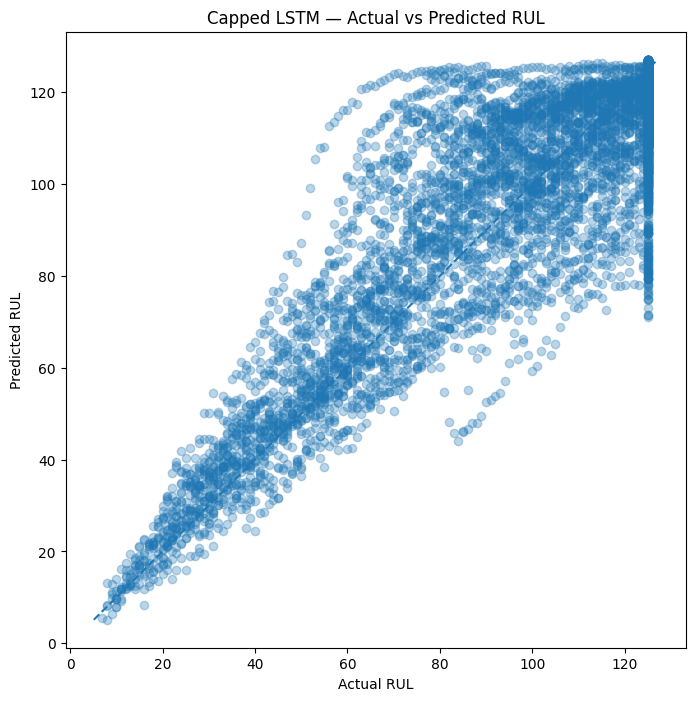

In [144]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test_lstm_50_cap,
    y_pred_test_cap,
    alpha=0.3
)

min_val = min(
    y_test_lstm_50_cap.min(),
    y_pred_test_cap.min()
)

max_val = max(
    y_test_lstm_50_cap.max(),
    y_pred_test_cap.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Capped LSTM — Actual vs Predicted RUL")

plt.show()

In [145]:
test_cap_analysis = pd.DataFrame({
    "actual_rul": y_test_lstm_50_cap,
    "predicted_rul": y_pred_test_cap
})

test_cap_analysis["error"] = (
    test_cap_analysis["actual_rul"]
    - test_cap_analysis["predicted_rul"]
)

test_cap_analysis["abs_error"] = (
    test_cap_analysis["error"].abs()
)

print(test_cap_analysis["error"].describe())
print()
print("Mean error:", test_cap_analysis["error"].mean())
print("Max absolute error:", test_cap_analysis["abs_error"].max())

count    8162.000000
mean        0.983079
std        14.083623
min       -57.738297
25%        -5.177263
50%         2.527977
75%         8.228489
max        53.876877
Name: error, dtype: float64

Mean error: 0.983078674427641
Max absolute error: 57.73829650878906


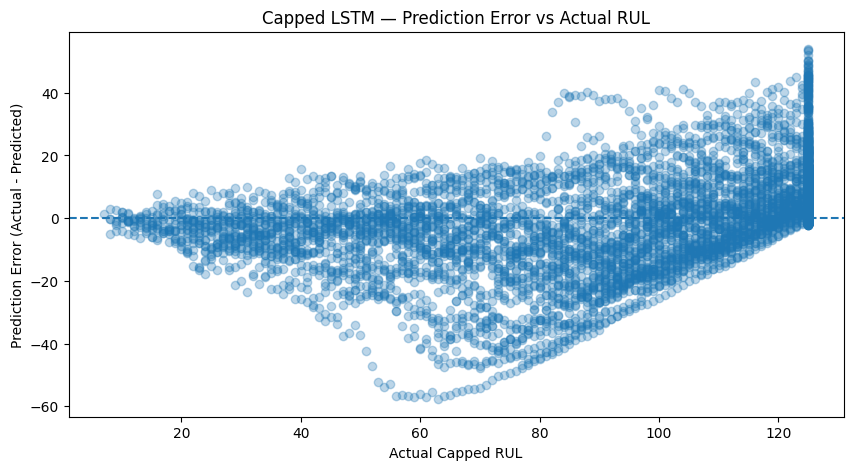

In [146]:
plt.figure(figsize=(10, 5))

plt.scatter(
    test_cap_analysis["actual_rul"],
    test_cap_analysis["error"],
    alpha=0.3
)

plt.axhline(0, linestyle="--")

plt.xlabel("Actual Capped RUL")
plt.ylabel("Prediction Error (Actual - Predicted)")
plt.title("Capped LSTM — Prediction Error vs Actual RUL")

plt.show()

In [147]:
# Create metadata for the test sequences

test_sequence_meta = []

for engine_id, engine_data in test_scaled.groupby("unit_id"):

    engine_data = engine_data.sort_values("cycle")

    for i in range(SEQUENCE_LENGTH_50, len(engine_data)):

        test_sequence_meta.append({
            "unit_id": engine_id,
            "cycle": engine_data.iloc[i]["cycle"]
        })

test_sequence_meta = pd.DataFrame(test_sequence_meta)

test_sequence_meta["actual_rul"] = y_test_lstm_50_cap
test_sequence_meta["predicted_rul"] = y_pred_test_cap

print(test_sequence_meta.head())
print("Shape:", test_sequence_meta.shape)

   unit_id  cycle  actual_rul  predicted_rul
0        3   51.0         125     109.477936
1        3   52.0         125     109.624512
2        3   53.0         125     110.997070
3        3   54.0         125     112.705139
4        3   55.0         125     110.916702
Shape: (8162, 4)


In [148]:
engine_counts = (
    test_sequence_meta
    .groupby("unit_id")
    .size()
    .sort_values(ascending=False)
)

print(engine_counts.head(10))

unit_id
49     253
93     194
91     184
62     182
12     167
81     163
76     155
34     153
100    148
35     148
dtype: int64


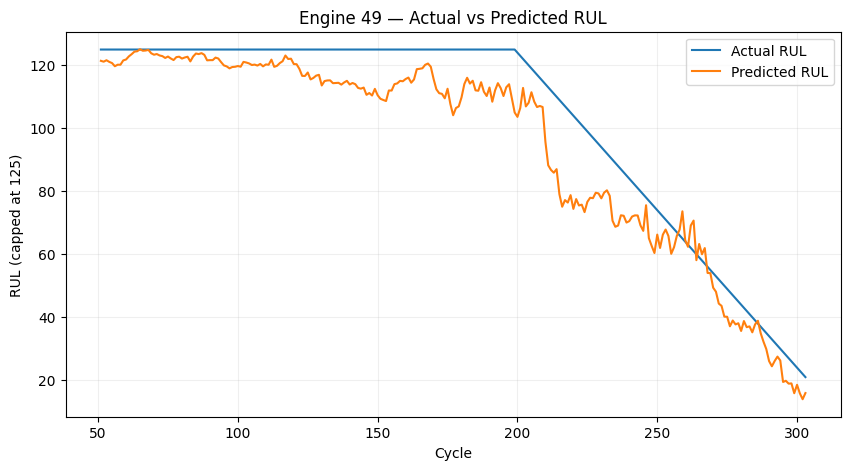

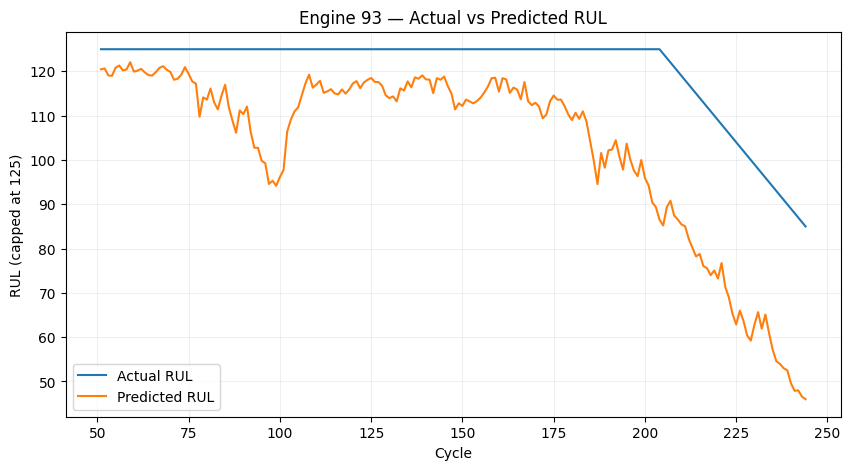

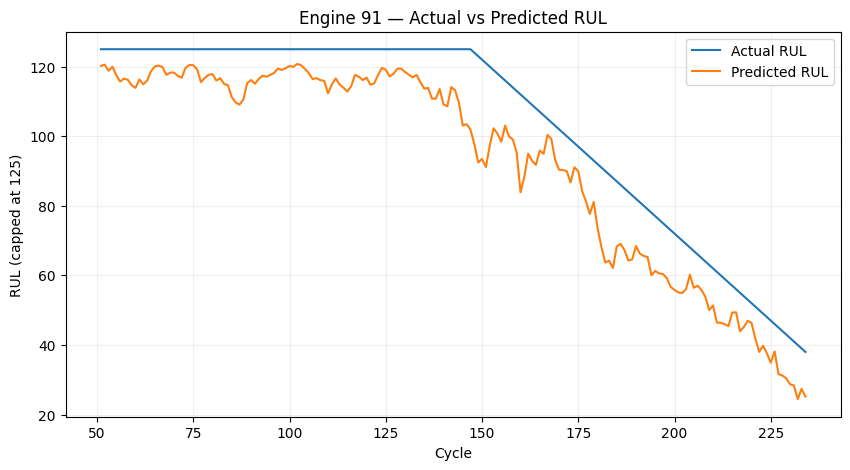

In [149]:
selected_engines = [49, 93, 91]

for engine_id in selected_engines:

    engine_data = test_sequence_meta[
        test_sequence_meta["unit_id"] == engine_id
    ].sort_values("cycle")

    plt.figure(figsize=(10, 5))

    plt.plot(
        engine_data["cycle"],
        engine_data["actual_rul"],
        label="Actual RUL"
    )

    plt.plot(
        engine_data["cycle"],
        engine_data["predicted_rul"],
        label="Predicted RUL"
    )

    plt.xlabel("Cycle")
    plt.ylabel("RUL (capped at 125)")
    plt.title(f"Engine {engine_id} — Actual vs Predicted RUL")
    plt.legend()
    plt.grid(alpha=0.2)

    plt.show()

In [150]:
for engine_id in selected_engines:

    engine_data = test_sequence_meta[
        test_sequence_meta["unit_id"] == engine_id
    ]

    engine_mae = mean_absolute_error(
        engine_data["actual_rul"],
        engine_data["predicted_rul"]
    )

    print(
        f"Engine {engine_id} MAE: {engine_mae:.2f}"
    )

Engine 49 MAE: 9.16
Engine 93 MAE: 17.60
Engine 91 MAE: 11.58


In [151]:
import os

os.makedirs("models", exist_ok=True)

lstm_model_50_cap.save(
    "models/lstm_50_capped.keras"
)

print("Model saved successfully!")

Model saved successfully!


In [152]:
print(os.listdir("models"))

['lstm_50_capped.keras']


In [153]:
import joblib

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [154]:
print(os.listdir("models"))

['scaler.pkl', 'lstm_50_capped.keras']


In [155]:
import json

model_config = {
    "sequence_length": 50,
    "rul_cap": 125,
    "lstm_features": lstm_features
}

with open(
    "models/model_config.json",
    "w"
) as f:
    json.dump(model_config, f, indent=4)

print("Configuration saved!")

Configuration saved!


In [156]:
print(os.listdir("models"))

['scaler.pkl', 'model_config.json', 'lstm_50_capped.keras']


In [158]:
print("=" * 100)
print("MODEL EVALUATION RESULTS FROM CURRENT COLAB RUNTIME")
print("=" * 100)

metric_vars = {}

# Make a fixed copy before iterating
current_vars = list(globals().items())

for name, value in current_vars:
    if name.startswith("_"):
        continue

    name_lower = name.lower()

    # Look for variables containing evaluation metric names
    if any(metric in name_lower for metric in ["mae", "rmse", "r2"]):

        # Only numeric values
        if isinstance(value, (int, float)):
            metric_vars[name] = value

if not metric_vars:
    print("\n❌ No evaluation metric variables found.")
else:
    print("\nEvaluation variables found:\n")

    for name, value in sorted(metric_vars.items()):
        print(f"{name:<50} : {value:.6f}")

print("\n" + "=" * 100)

MODEL EVALUATION RESULTS FROM CURRENT COLAB RUNTIME

Evaluation variables found:

engine_mae                                         : 11.583346
mae                                                : 25.861968
mae_baseline_fair                                  : 23.448203
mae_lstm                                           : 16.873823
mae_lstm_50                                        : 13.635752
mae_no_cycle                                       : 24.668727
mae_rf_fair                                        : 21.800543
mae_temporal                                       : 24.203093
mae_test                                           : 24.810402
mae_test_cap                                       : 10.221842
mae_val_cap                                        : 8.240742
mae_xgb                                            : 24.535295
mae_xgb_fair                                       : 22.252468
r2                                                 : 0.710091
r2_baseline_fair                      

In [159]:
import json

metrics = {
    "model": "LSTM_50_Capped",
    "sequence_length": 50,
    "rul_cap": 125,
    "validation": {
        "mae": float(mae_val_cap),
        "rmse": float(rmse_val_cap),
        "r2": float(r2_val_cap)
    },
    "test": {
        "mae": float(mae_test_cap),
        "rmse": float(rmse_test_cap),
        "r2": float(r2_test_cap)
    }
}

with open("models/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("metrics.json created successfully!")
print(json.dumps(metrics, indent=4))

metrics.json created successfully!
{
    "model": "LSTM_50_Capped",
    "sequence_length": 50,
    "rul_cap": 125,
    "validation": {
        "mae": 8.240741729736328,
        "rmse": 11.314325512022013,
        "r2": 0.9247291088104248
    },
    "test": {
        "mae": 10.221841812133789,
        "rmse": 14.117031854426987,
        "r2": 0.7981798648834229
    }
}


In [160]:
print(os.listdir("models"))

['scaler.pkl', 'metrics.json', 'model_config.json', 'lstm_50_capped.keras']


In [161]:
import shutil
import os

shutil.make_archive(
    "predictive_maintenance_models",
    "zip",
    "models"
)

print("Created: predictive_maintenance_models.zip")

Created: predictive_maintenance_models.zip


In [162]:
from google.colab import files

files.download("predictive_maintenance_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>